In [1]:

#Importing Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import r2_score

In [6]:
#reading the dataset
zomato_real=pd.read_csv("/content/zomato.csv", on_bad_lines='skip', engine='python')
zomato_real.head() # prints the first N rows of a DataFrame

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [7]:
zomato_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17437 entries, 0 to 17436
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          17437 non-null  object
 1   address                      17437 non-null  object
 2   name                         17437 non-null  object
 3   online_order                 17437 non-null  object
 4   book_table                   17437 non-null  object
 5   rate                         14769 non-null  object
 6   votes                        17437 non-null  int64 
 7   phone                        17075 non-null  object
 8   location                     17433 non-null  object
 9   rest_type                    17364 non-null  object
 10  dish_liked                   7608 non-null   object
 11  cuisines                     17424 non-null  object
 12  approx_cost(for two people)  17386 non-null  object
 13  reviews_list                 17

In [8]:
#Deleting Unnnecessary Columns
zomato=zomato_real.drop(['url','dish_liked','phone'],axis=1) #Dropping the column "dish_liked", "phone", "url" and saving the new dataset as "zomato"

In [9]:
#Removing the Duplicates
zomato.duplicated().sum()
zomato.drop_duplicates(inplace=True)

In [10]:
#Remove the NaN values from the dataset
zomato.isnull().sum()
zomato.dropna(how='any',inplace=True)
zomato.info() #.info() function is used to get a concise summary of the dataframe

<class 'pandas.core.frame.DataFrame'>
Index: 14659 entries, 0 to 17436
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      14659 non-null  object
 1   name                         14659 non-null  object
 2   online_order                 14659 non-null  object
 3   book_table                   14659 non-null  object
 4   rate                         14659 non-null  object
 5   votes                        14659 non-null  int64 
 6   location                     14659 non-null  object
 7   rest_type                    14659 non-null  object
 8   cuisines                     14659 non-null  object
 9   approx_cost(for two people)  14659 non-null  object
 10  reviews_list                 14659 non-null  object
 11  menu_item                    14659 non-null  object
 12  listed_in(type)              14659 non-null  object
 13  listed_in(city)              14659 n

In [12]:
#Reading Column Names
zomato.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [13]:
#Changing the column names
zomato = zomato.rename(columns={'approx_cost(for two people)':'cost','listed_in(type)':'type',
                                  'listed_in(city)':'city'})
zomato.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'cost', 'reviews_list',
       'menu_item', 'type', 'city'],
      dtype='object')

In [14]:
#Some Transformations
zomato['cost'] = zomato['cost'].astype(str) #Changing the cost to string
zomato['cost'] = zomato['cost'].apply(lambda x: x.replace(',','.')) #Using lambda function to replace ',' from cost
zomato['cost'] = zomato['cost'].astype(float) # Changing the cost to Float
zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14659 entries, 0 to 17436
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   address       14659 non-null  object 
 1   name          14659 non-null  object 
 2   online_order  14659 non-null  object 
 3   book_table    14659 non-null  object 
 4   rate          14659 non-null  object 
 5   votes         14659 non-null  int64  
 6   location      14659 non-null  object 
 7   rest_type     14659 non-null  object 
 8   cuisines      14659 non-null  object 
 9   cost          14659 non-null  float64
 10  reviews_list  14659 non-null  object 
 11  menu_item     14659 non-null  object 
 12  type          14659 non-null  object 
 13  city          14659 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 1.7+ MB


In [15]:
#Reading Rate of dataset
zomato['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5'], dtype=object)

In [17]:
#Removing '/5' from Rates
zomato = zomato.loc[zomato.rate !='NEW']
zomato = zomato.loc[zomato.rate !='-'].reset_index(drop=True)
remove_slash = lambda x: x.replace('/5', '') if type(x) == str else x
zomato.rate = zomato.rate.apply(remove_slash).str.strip().astype('float')
zomato['rate'].head()

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


In [18]:
# Adjust the column names
zomato.name = zomato.name.apply(lambda x:x.title())
zomato.online_order.replace(('Yes','No'),(True, False),inplace=True)
zomato.book_table.replace(('Yes','No'),(True, False),inplace=True)
zomato.cost.unique()

/tmp/ipykernel_6793/922587314.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  zomato.online_order.replace(('Yes','No'),(True, False),inplace=True)
/tmp/ipykernel_6793/922587314.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  zomato.online_order.replace(('Yes','No'),(True, False),inplace=True

array([800.  , 300.  , 600.  , 700.  , 550.  , 500.  , 450.  , 650.  ,
       400.  , 900.  , 200.  , 750.  , 150.  , 850.  , 100.  ,   1.2 ,
       350.  , 250.  , 950.  ,   1.  ,   1.5 ,   1.3 , 199.  ,   1.1 ,
         1.6 , 230.  , 130.  ,   1.7 ,   1.35,   2.2 ,   1.4 ,   2.  ,
         1.8 ,   1.9 , 180.  , 330.  ,   2.5 ,   2.1 ,   3.  ,   2.8 ,
         3.4 ,  50.  ,  40.  ,   1.25,   3.5 ,   4.  ,   2.4 ,   2.6 ,
         1.45,  70.  ,   3.2 ])

In [19]:
#Encode the input Variables
def Encode(zomato):
    for column in zomato.columns[~zomato.columns.isin(['rate', 'cost', 'votes'])]:
        zomato[column] = zomato[column].factorize()[0]
    return zomato

zomato_en = Encode(zomato.copy())


In [20]:
#Defining the independent variables and dependent variables
x = zomato_en.iloc[:,[2,3,5,6,7,8,9,11]]
y = zomato_en['rate']
#Getting Test and Training Set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.1,random_state=353)
x_train.head()
y_train.head()

,rate
1463,3.8
5179,3.2
8336,3.8
10557,4.6
11024,3.4


In [21]:
#Prepare a Linear Regression Model
reg=LinearRegression()
reg.fit(x_train,y_train)
y_pred=reg.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.28196018319351057

In [22]:
#Prepairng a Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.1,random_state=105)
DTree=DecisionTreeRegressor(min_samples_leaf=.0001)
DTree.fit(x_train,y_train)
y_predict=DTree.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.7104269320470997

In [23]:
#Preparing Random Forest REgression
from sklearn.ensemble import RandomForestRegressor
RForest=RandomForestRegressor(n_estimators=500,random_state=329,min_samples_leaf=.0001)
RForest.fit(x_train,y_train)
y_predict=RForest.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.8001948245900794

In [24]:
from sklearn.ensemble import  ExtraTreesRegressor
ETree=ExtraTreesRegressor(n_estimators = 100)
ETree.fit(x_train,y_train)
y_predict=ETree.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.8695118676557181

/tmp/ipykernel_6793/1788847905.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chains.index,y=chains, palette='tab10')


Text(0, 0.5, 'Number of outlets')

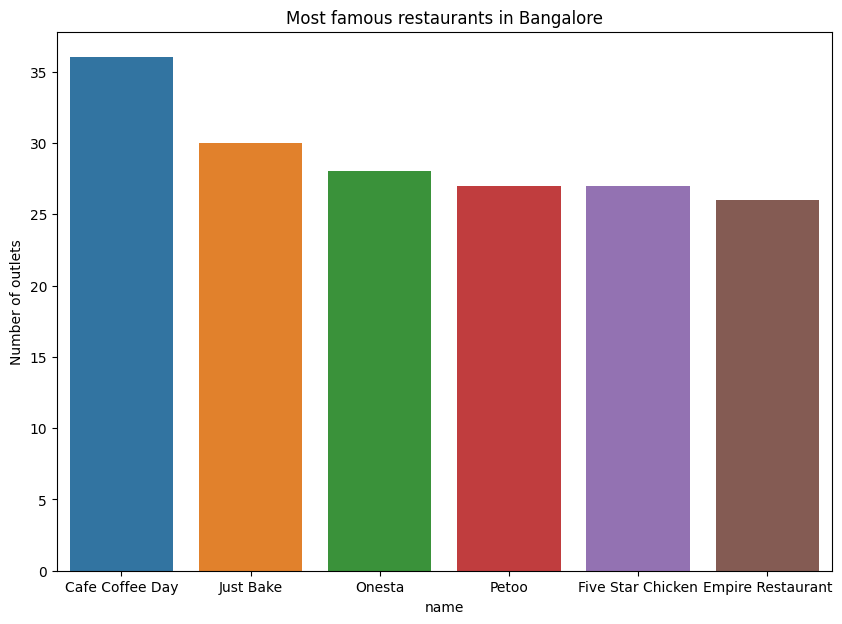

In [25]:
#Most Famous 6 restaurants in Banglore

plt.figure(figsize=(10,7))

chains=zomato_real['name'].value_counts() [:6]

sns.barplot(x=chains.index,y=chains, palette='tab10')

plt.title("Most famous restaurants in Bangalore")

plt.ylabel("Number of outlets")

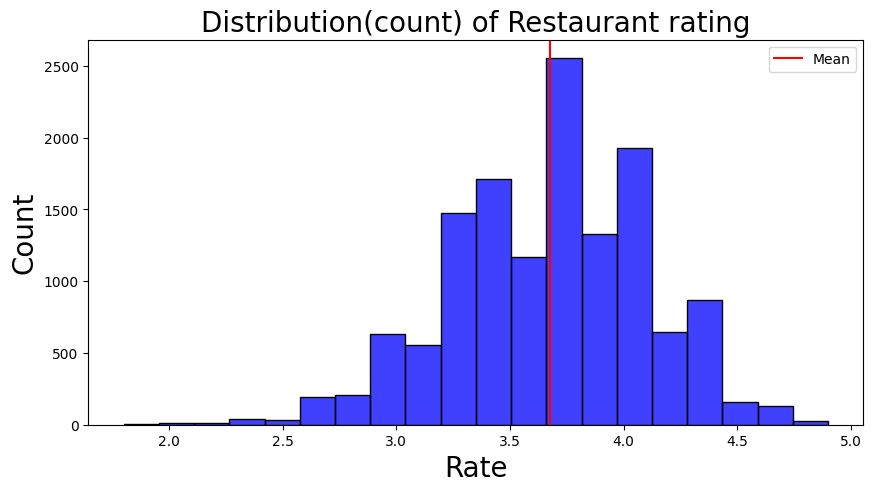

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
sns.histplot(zomato.rate, kde=False, color='b', ax=ax, bins=20);
ax.axvline(zomato.rate.mean(), 0, 1, color='r', label='Mean')
ax.legend();
ax.set_ylabel('Count',size=20)
ax.set_xlabel('Rate',size=20)
ax.set_title('Distribution(count) of Restaurant rating',size=20);

/tmp/ipykernel_6793/1195802174.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rating, x='Mean Rating', y='name', palette='RdBu')


Text(0, 0.5, 'Restaurant Name')

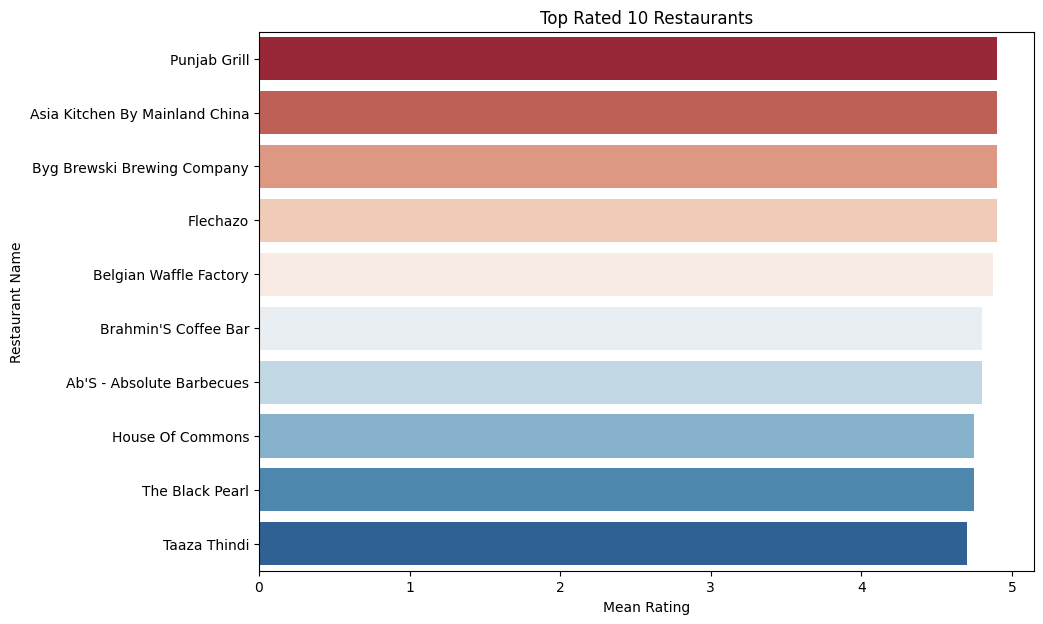

In [31]:
# Calculate the mean rating for each unique restaurant name using the cleaned 'rate' column from 'zomato'
df_mean_ratings = zomato.groupby('name')['rate'].mean().reset_index()
df_mean_ratings.rename(columns={'rate': 'Mean Rating'}, inplace=True)

# Sort by 'Mean Rating' to get the top 10
df_rating = df_mean_ratings.sort_values(by='Mean Rating', ascending=False).head(10)

plt.figure(figsize=(10,7))
sns.barplot(data=df_rating, x='Mean Rating', y='name', palette='RdBu')
plt.title('Top Rated 10 Restaurants');
plt.xlabel('Mean Rating')
plt.ylabel('Restaurant Name')

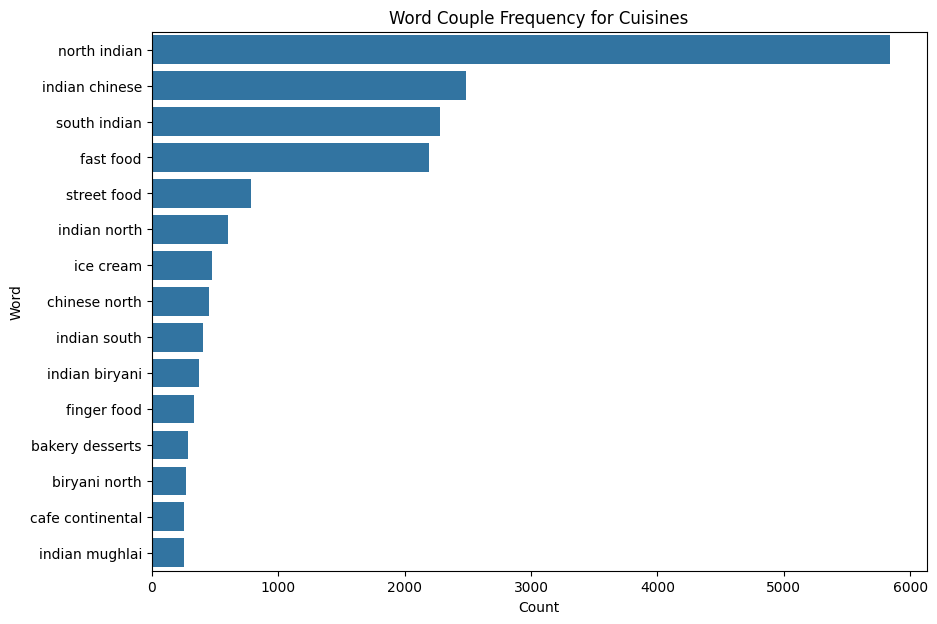

In [33]:
# Top 15 two word frequencies for Cuisines
# The function get_top_words is not defined in the current notebook state.
# You would need to define this function to extract word frequencies.
# Assuming get_top_words returns a list of tuples like [('word1 word2', count), ...]

# Placeholder for get_top_words implementation:
def get_top_words(series, top_n, ngram_range=(1,1)):
    from collections import Counter
    import re
    all_words = []
    for item in series.dropna():
        # Clean the string, remove non-alphabetic characters and convert to lowercase
        cleaned_item = re.sub('[^a-zA-Z ]', '', item).lower()
        words = cleaned_item.split()
        for i in range(len(words) - ngram_range[1] + 1):
            for j in range(ngram_range[0], ngram_range[1] + 1):
                if i + j <= len(words):
                    ngram = ' '.join(words[i:i+j])
                    all_words.append(ngram)
    word_counts = Counter(all_words)
    return word_counts.most_common(top_n)

lst = get_top_words(zomato['cuisines'], 15, (2,2))
df_words = pd.DataFrame(lst, columns=['Word', 'Count'])
plt.figure(figsize=(10,7))
sns.barplot(data=df_words, x='Count', y='Word')
plt.title('Word Couple Frequency for Cuisines');

In [43]:
zomato.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,reviews_list,menu_item,type,city
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [44]:
zomato['city'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar'],
      dtype=object)

In [45]:
zomato.isnull().sum()

,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
cuisines,0
cost,0


In [47]:
# Ensure the 'rate' column is in a numeric format.
# This step addresses the TypeError by converting the 'rate' column from string (e.g., '4.1/5') to float.
# This is crucial because the error indicates that the 'rate' column is not numeric when .mean() is called.
# The previous cleaning cell (geSJcixpGAew) should have done this, but the current state indicates it needs re-application or verification.
if zomato['rate'].dtype == 'object':
    # Create a temporary copy for cleaning to avoid potential SettingWithCopyWarning if 'zomato' is a slice
    cleaned_rates_df = zomato.copy()
    cleaned_rates_df = cleaned_rates_df[cleaned_rates_df['rate'] != 'NEW']
    cleaned_rates_df = cleaned_rates_df[cleaned_rates_df['rate'] != '-']
    cleaned_rates_df['rate'] = cleaned_rates_df['rate'].apply(lambda x: x.replace('/5', '') if isinstance(x, str) else x).str.strip().astype(float)
else:
    cleaned_rates_df = zomato.copy()

# Calculate the mean rating for each restaurant and assign it to a new 'Mean Rating' column.
# Using groupby().transform('mean') is an efficient and idiomatic pandas way to achieve this,
# broadcasting the mean of each group ('name') back to all rows belonging to that group.
zomato['Mean Rating'] = cleaned_rates_df.groupby('name')['rate'].transform('mean')

In [48]:
zomato.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,reviews_list,menu_item,type,city,Mean Rating
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,4.114286
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,4.100000
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.800000
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,3.700000
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,3.800000


In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (1,5))

zomato[['Mean Rating']] = scaler.fit_transform(zomato[['Mean Rating']]).round(2)

zomato.sample(3)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,reviews_list,menu_item,type,city,Mean Rating
13517,"Basement 2064, Siri Iris Building, 24th Main, ...",Delite Chaat House,Yes,No,3.4/5,179,HSR,Quick Bites,"Street Food, Gujarati",300.0,"[('Rated 3.0', 'RATED\n Ordered dahi kachori ...",[],Dine-out,HSR,3.35
3493,"8A & 8B, RMZ Ecoworld, Doddakannelli Road, Ada...",Taste Of India,No,No,3.1/5,5,Bellandur,Quick Bites,"North Indian, Rolls",400.0,"[('Rated 3.0', 'RATED\n Decent Indian food in...",[],Delivery,Bellandur,2.68
13163,"581, Ground Floor, 22nd Cross Road, HSR Club R...",Donne Biriyani House,Yes,No,3.2/5,73,HSR,Quick Bites,"Biryani, South Indian",400.0,"[('Rated 3.0', 'RATED\n Average place. Lacks ...",[],Delivery,HSR,3.32


In [50]:
zomato.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,reviews_list,menu_item,type,city,Mean Rating
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,3.99
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,3.97
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.58
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,3.45
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,3.58


In [51]:
zomato[['reviews_list', 'cuisines']].sample(5)

,reviews_list,cuisines
863,"[('Rated 5.0', 'RATED\n Love all KFC places. ...","Burger, Fast Food"
13537,"[('Rated 5.0', ""RATED\n A wonderful kerala re...",Kerala
949,"[('Rated 1.0', 'RATED\n Not good paneer roll....","Fast Food, North Indian, Chinese, Mughlai, Rolls"
9849,"[('Rated 5.0', 'RATED\n I love croons they ma...",Desserts
3321,"[('Rated 4.0', 'RATED\n Mumbai vadapav in the...","Fast Food, Street Food"


In [52]:
## Lower Casing
zomato["reviews_list"] = zomato["reviews_list"].str.lower()
zomato[['reviews_list', 'cuisines']].sample(5)

,reviews_list,cuisines
2700,"[('rated 2.0', 'rated\n it was raining and p...",Chinese
1384,"[('rated 3.0', ""rated\n ok. i don't know what...",Rajasthani
4589,"[('rated 3.0', ""rated\n we had the combo meal...","North Indian, Chinese"
12184,"[('rated 3.0', 'rated\n the restaurant is loc...","North Indian, Chinese, Biryani, Kebab, Juices"
11211,"[('rated 5.0', 'rated\n introduced to this ho...","Kerala, Biryani, Chinese, North Indian"


In [53]:

import string
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    """custom function to remove the punctuation"""
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

zomato["reviews_list"] = zomato["reviews_list"].apply(lambda text: remove_punctuation(text))
zomato[['reviews_list', 'cuisines']].sample(5)

,reviews_list,cuisines
11640,rated 40 ratedn this place is located near to...,"North Indian, Street Food"
10733,rated 30 ratedn i would loved to have this pl...,"North Indian, Chinese, Japanese, European, Sea..."
12902,rated 40 ratedn we had ordered food from this...,South Indian
2626,rated 50 ratedn this is a cute small place se...,North Indian
6175,rated 50 ratedn i ordered a choco mocha cake ...,Desserts


In [55]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
    """custom function to remove the stopwords"""
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

zomato["reviews_list"] = zomato["reviews_list"].apply(lambda text: remove_stopwords(text))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [57]:
import re
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

zomato["reviews_list"] = zomato["reviews_list"].apply(lambda text: remove_urls(text))

In [58]:
zomato[['reviews_list', 'cuisines']].sample(5)

,reviews_list,cuisines
1705,rated 50 ratedn best place steakespecially por...,"Chinese, North Indian, Fast Food, Momos"
4460,rated 40 ratedn ordered chicken tikka roll pan...,"North Indian, Chinese, Biryani"
1568,rated 50 ratedn relief find restaurant banergh...,"Chinese, Thai"
11798,rated 40 ratedn ordered chicken tikka roll pan...,"North Indian, Chinese, Biryani"
368,rated 50 ratedn love pomegranate juice tasty r...,"South Indian, North Indian, Chinese"


In [59]:
def get_top_words(column, top_nu_of_words, nu_of_word):

    vec = CountVectorizer(ngram_range= nu_of_word, stop_words='english')

    bag_of_words = vec.fit_transform(column)

    sum_words = bag_of_words.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)

    return words_freq[:top_nu_of_words]

In [60]:
zomato.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,reviews_list,menu_item,type,city,Mean Rating
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,rated 40 ratedn beautiful place dine inthe int...,[],Buffet,Banashankari,3.99
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,rated 40 ratedn dinner family turned good choo...,[],Buffet,Banashankari,3.97
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,rated 30 ratedn ambience good enough pocket fr...,[],Buffet,Banashankari,3.58
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,rated 40 ratedn great food proper karnataka st...,[],Buffet,Banashankari,3.45
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,rated 40 ratedn good restaurant neighbourhood ...,[],Buffet,Banashankari,3.58


In [61]:
zomato.sample(5)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,reviews_list,menu_item,type,city,Mean Rating
1602,"Akshay Nagar, Bannerghatta Road, Bangalore",Bella?s Kitchen,No,No,2.9/5,31,Bannerghatta Road,Casual Dining,"Chinese, Seafood, North Indian",600.0,rated 30 ratedn tried place weekday dinner sur...,[],Dine-out,Bannerghatta Road,2.42
7116,"Munireddy Eeramma Kalyana Mantapa, Koramangala...",Bawarchi Biryani,Yes,No,3.4/5,65,Koramangala 6th Block,Quick Bites,"Biryani, South Indian",350.0,rated 40 ratedn ambience good well chilled pla...,[],Delivery,BTM,3.06
5478,"36/3, Ramagandanahalli, Varthur Main Road, Whi...",Teashot,No,No,2.9/5,24,Whitefield,Cafe,Cafe,150.0,rated 35 ratedn earlier go place tea however l...,[],Cafes,Brookefield,2.42
5378,"9, 4th Floor, Halcyon Complex, St. Marks Road,...",The Open Box,Yes,Yes,4.2/5,2270,St. Marks Road,"Casual Dining, Bar","European, North Indian, Mediterranean, Asian, ...",1.4,rated 40 ratedn weekday check new menu first t...,[],Pubs and bars,Brigade Road,4.10
5551,"8, 5th Cross, Ramanjineya Layout, Oppsite Kala...",Handi Biryani,Yes,No,3.9/5,84,Marathahalli,Quick Bites,"Hyderabadi, Biryani",300.0,rated 40 ratedn since delivery place worked fi...,[],Delivery,Brookefield,3.71


In [62]:
zomato.shape

(13699, 15)

In [63]:
zomato.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'cost', 'reviews_list',
       'menu_item', 'type', 'city', 'Mean Rating'],
      dtype='object')

In [64]:
zomato=zomato.drop(['address','rest_type', 'type', 'menu_item', 'votes'],axis=1)

In [65]:
import pandas

df_percent = zomato.sample(frac=0.5)

In [66]:
df_percent.shape

(6850, 10)

In [67]:
df_percent.set_index('name', inplace=True)

In [68]:
indices = pd.Series(df_percent.index)

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Creating tf-idf matrix
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=1, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_percent['reviews_list'])

In [73]:
from sklearn.metrics.pairwise import linear_kernel
cosine_similarities = linear_kernel(tfidf_matrix, tfidf_matrix)

In [74]:
def recommend(name, cosine_similarities = cosine_similarities):


    recommend_restaurant = []


    idx = indices[indices == name].index[0]


    score_series = pd.Series(cosine_similarities[idx]).sort_values(ascending=False)


    top30_indexes = list(score_series.iloc[0:31].index)


    for each in top30_indexes:
        recommend_restaurant.append(list(df_percent.index)[each])


    df_new = pd.DataFrame(columns=['cuisines', 'Mean Rating', 'cost'])


    for each in recommend_restaurant:
        df_new = df_new.append(pd.DataFrame(df_percent[['cuisines','Mean Rating', 'cost']][df_percent.index == each].sample()))


    df_new = df_new.drop_duplicates(subset=['cuisines','Mean Rating', 'cost'], keep=False)
    df_new = df_new.sort_values(by='Mean Rating', ascending=False).head(10)

    print('TOP %s RESTAURANTS LIKE %s WITH SIMILAR REVIEWS: ' % (str(len(df_new)), name))

    return df_new

In [75]:
df_percent[df_percent.index == 'Pai Vihar'].head()

,online_order,book_table,rate,location,cuisines,cost,reviews_list,city,Mean Rating
name,,,,,,,,,
Pai Vihar,Yes,No,2.8/5,Vasanth Nagar,"South Indian, Street Food, Chinese, Fast Food",400.0,rated 30 ratedn 12 rate herenneven though tast...,Church Street,2.46
Pai Vihar,No,No,3.2/5,City Market,"South Indian, Street Food, Chinese, Fast Food",400.0,rated 20 ratedn food dry bland dont understand...,Brigade Road,2.46


In [83]:
def recommend(name, cosine_similarities = cosine_similarities):


    recommend_restaurant = []

    # Check if the name exists in the indices Series
    if name not in indices.values:
        print(f"Restaurant '{name}' not found in the dataset. Please try a different name.")
        return pd.DataFrame(columns=['cuisines', 'Mean Rating', 'cost']) # Return an empty DataFrame

    idx = indices[indices == name].index[0]


    score_series = pd.Series(cosine_similarities[idx]).sort_values(ascending=False)


    top30_indexes = list(score_series.iloc[0:31].index)


    for each in top30_indexes:
        recommend_restaurant.append(list(df_percent.index)[each])


    df_new = pd.DataFrame(columns=['cuisines', 'Mean Rating', 'cost'])


    # Use pd.concat instead of append
    temp_df_list = []
    for each in recommend_restaurant:
        temp_df_list.append(df_percent[['cuisines','Mean Rating', 'cost']][df_percent.index == each].sample())

    if temp_df_list:
        df_new = pd.concat(temp_df_list)


    df_new = df_new.drop_duplicates(subset=['cuisines','Mean Rating', 'cost'], keep=False)
    df_new = df_new.sort_values(by='Mean Rating', ascending=False).head(10)

    print('TOP %s RESTAURANTS LIKE %s WITH SIMILAR REVIEWS: ' % (str(len(df_new)), name))

    return df_new

recommend('Pai Vihar')

TOP 10 RESTAURANTS LIKE Pai Vihar WITH SIMILAR REVIEWS: 


,cuisines,Mean Rating,cost
name,,,
Samosa Singh,"Street Food, Beverages",3.69,150.0
Samosa Singh,"Street Food, Fast Food, Rolls, Desserts",3.69,200.0
New Friends,"North Indian, Continental, Chinese, Steak",3.58,900.0
Pallavi Restaurant,"Biryani, Chinese, Andhra",3.58,500.0
Magix's Parattha Roll,"Fast Food, North Indian, Chinese, Mughlai, Rolls",3.45,400.0
Prasiddhi Food Corner,"Fast Food, North Indian, South Indian",3.45,200.0
Sri Sai Mango Tree Restaurant,"North Indian, Biryani, Chinese",3.32,600.0
Dakshin Kitchen,South Indian,3.32,100.0
Sri Sai Bhavan,South Indian,3.32,300.0


In [85]:
import pickle

with open("zomato_recommender.pkl", "wb") as f:
    pickle.dump({
        "tfidf": tfidf,
        "tfidf_matrix": tfidf_matrix,
        "cosine_similarities": cosine_similarities,
        "data": zomato_real,
        "indices": indices
    }, f)